In [31]:
# Test: Gibt es überhaupt einen Pfad zum Ziel?
import numpy as np
from collections import deque

def find_path_bfs(env, start, goal):
    """Breadth-First Search um zu prüfen ob ein Pfad existiert"""
    queue = deque([start])
    visited = {start}
    parent = {start: None}
    
    while queue:
        current = queue.popleft()
        
        if current == goal:
            # Rekonstruiere Pfad
            path = []
            while current is not None:
                path.append(current)
                current = parent[current]
            return list(reversed(path))
        
        # Prüfe alle 4 Richtungen
        for action in ["up", "down", "left", "right"]:
            next_pos = list(current)
            if action == "up":
                next_pos[0] = max(0, current[0] - 1)
            elif action == "down":
                next_pos[0] = min(env.shape[0] - 1, current[0] + 1)
            elif action == "left":
                next_pos[1] = max(0, current[1] - 1)
            elif action == "right":
                next_pos[1] = min(env.shape[1] - 1, current[1] + 1)
            
            next_pos = tuple(next_pos)
            
            # Überspringe Berge (unpassierbar)
            if next_pos in env.obstacles.get("mountain", []):
                continue
                
            if next_pos not in visited:
                visited.add(next_pos)
                parent[next_pos] = current
                queue.append(next_pos)
    
    return None  # Kein Pfad gefunden

# Teste ob Pfad existiert
print("Prüfe ob Pfad existiert...")
print(f"Start: {grid_config.start_position}")
print(f"Ziel: {grid_config.goal_position}")
print(f"Grid: {grid_config.shape}")
print(f"Hindernisse: {len(river_positions)} Flüsse, {len(swamp_positions)} Moore, {len(mountain_positions)} Berge")

path = find_path_bfs(env, grid_config.start_position, grid_config.goal_position)

if path:
    print(f"\n✓ Pfad existiert! Länge: {len(path)-1} Schritte")
    print(f"Pfad: {path[:10]}..." if len(path) > 10 else f"Pfad: {path}")
else:
    print("\n✗ KEIN PFAD MÖGLICH! Das Ziel ist durch Berge blockiert!")
    print("→ Der Agent kann das Ziel niemals erreichen!")

Prüfe ob Pfad existiert...
Start: (23, 0)
Ziel: (6, 17)
Grid: (24, 24)
Hindernisse: 45 Flüsse, 53 Moore, 73 Berge

✓ Pfad existiert! Länge: 34 Schritte
Pfad: [(23, 0), (22, 0), (21, 0), (20, 0), (19, 0), (18, 0), (17, 0), (16, 0), (15, 0), (14, 0)]...


In [19]:
%reset -f

## Imports

In [20]:
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Literal, get_args
import numpy as np
import random
import tensorflow as tf
from collections import deque

## GPU Konfiguration (MacBook Pro)

In [21]:
# GPU Setup für MacBook Pro (Apple Silicon M1/M2/M3)
# Für Intel Macs: automatische GPU-Erkennung

# Prüfe verfügbare Geräte
print("TensorFlow Version:", tf.__version__)
print("\nVerfügbare Geräte:")
for device in tf.config.list_physical_devices():
    print(f"  - {device.device_type}: {device.name}")

# GPU-Speicher dynamisch wachsen lassen (empfohlen für MacBooks)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"\n✓ GPU gefunden und konfiguriert: {len(gpus)} GPU(s)")
        print("  Memory Growth aktiviert (dynamische Speicherzuweisung)")
    except RuntimeError as e:
        print(f"GPU Konfigurationsfehler: {e}")
else:
    print("\n⚠ Keine GPU gefunden - Training läuft auf CPU")
    print("\nFür Apple Silicon (M1/M2/M3) MacBooks:")
    print("  Installiere: pip install tensorflow-metal")
    print("\nFür Intel MacBooks:")
    print("  GPU-Beschleunigung erfordert externe GPU oder Cloud-Plattform")

TensorFlow Version: 2.16.1

Verfügbare Geräte:
  - CPU: /physical_device:CPU:0
  - GPU: /physical_device:GPU:0

✓ GPU gefunden und konfiguriert: 1 GPU(s)
  Memory Growth aktiviert (dynamische Speicherzuweisung)


## Configuration Data Classes

In [22]:
@dataclass
class TerrainCosts:
    """Kosten für verschiedene Terrain-Typen"""
    free: float
    river: float
    swamp: float
    mountain: float
    
    def to_dict(self) -> Dict[str, float]:
        """Konvertiert zu Dictionary für Kompatibilität"""
        return {
            'free': self.free,
            'river': self.river,
            'swamp': self.swamp,
            'mountain': self.mountain
        }

@dataclass
class ObstacleConfig:
    """Konfiguration für Hindernisse im Grid"""
    river_positions: List[Tuple[int, int]]
    swamp_positions: List[Tuple[int, int]]
    mountain_positions: List[Tuple[int, int]]
    
    def to_dict(self) -> Dict[str, List[Tuple[int, int]]]:
        """Konvertiert zu Dictionary für GridEnvironment"""
        return {
            "river": self.river_positions,
            "swamp": self.swamp_positions,
            "mountain": self.mountain_positions
        }
    
    def total_count(self) -> int:
        """Gibt die Gesamtanzahl aller Hindernisse zurück"""
        return len(self.river_positions) + len(self.swamp_positions) + len(self.mountain_positions)

@dataclass
class GridConfig:
    """Konfiguration für das Grid Environment"""
    shape: Tuple[int, int]
    start_position: Tuple[int, int]
    goal_position: Tuple[int, int]
    obstacles: ObstacleConfig

@dataclass
class RewardConfig:
    """Reward-Konfiguration"""
    goal_reward: float
    terrain_costs: TerrainCosts

@dataclass
class TrainingConfig:
    """Hyperparameter für DQN Training"""
    episodes: int
    learning_rate: float
    gamma: float
    epsilon_start: float
    epsilon_min: float
    batch_size: int
    max_steps: int
    verbose: bool

## Environment

In [23]:
# Movement types
_MOVETYPES = Literal["up", "down", "left", "right"]

# Obstacle types
_OBSTACLES = Literal["river", "swamp", "mountain"]

# GridEnvironment class (identisch mit gridworld.ipynb)
class GridEnvironment:
    def __init__(self, grid_config: GridConfig):
        """
        Generisches GridEnvironment mit Data Class Konfiguration.
        
        Args:
            grid_config: GridConfig Instanz mit allen Environment-Parametern
        """
        self.shape = grid_config.shape
        self.start_position = grid_config.start_position
        self.goal_position = grid_config.goal_position
        self.obstacles = grid_config.obstacles.to_dict()
        self.state = None
        self.reset()
    
    def reset(self):
        """Setzt den State auf die Startposition zurück."""
        self.state = self.start_position
        return self.state
    
    def give_reward(self, reward_config: RewardConfig):
        """
        Berechnet den Reward für den aktuellen State.
        
        Args:
            reward_config: RewardConfig mit Terrain-Kosten und Goal-Reward
        
        Returns:
            float: Reward-Wert
        """
        # Check for goal
        if self.state == self.goal_position:
            return reward_config.goal_reward
        
        # Get terrain costs dict
        terrain_costs = reward_config.terrain_costs.to_dict()
        
        # Check for obstacles
        for obstacle_type, positions in self.obstacles.items():
            if self.state in positions:
                return terrain_costs.get(obstacle_type, terrain_costs['free'])
        
        # Free field
        return terrain_costs['free']
    
    def is_terminal(self):
        """Prüft ob der aktuelle State ein Terminal-State ist."""
        return self.state == self.goal_position
    
    def step(self, action: _MOVETYPES, reward_config: RewardConfig):
        """
        Führt eine Aktion aus und gibt den nächsten State, Reward und Done-Flag zurück.
        
        Args:
            action: Aktion ("up", "down", "left", "right")
            reward_config: RewardConfig mit Terrain-Kosten und Goal-Reward
        
        Returns:
            tuple: (next_state, reward, done)
        """
        next_state = list(self.state)
        match(action):
            case "up":
                next_state[0] = max(0, self.state[0] - 1)
            case "down":
                next_state[0] = min(self.shape[0] - 1, self.state[0] + 1)
            case "left":
                next_state[1] = max(0, self.state[1] - 1)
            case "right":
                next_state[1] = min(self.shape[1] - 1, self.state[1] + 1)
        
        self.state = tuple(next_state)
        reward = self.give_reward(reward_config)
        done = self.is_terminal()
        
        return self.state, reward, done

## Base Agent Class

In [24]:
# Base Agent class
class Agent:
    def __init__(self, environment: GridEnvironment, actions: list = []):
        self.environment = environment
        self.actions = list(actions)
        self.action_space = len(self.actions)

## Deep Q-Network Agent

Der Deep Q-Network (DQN) Agent nutzt ein neuronales Netzwerk anstelle einer Q-Tabelle.

**Vorteile gegenüber Q-Learning:**
- Skaliert besser bei großen State-Spaces
- Kann Generalisierung zwischen ähnlichen States lernen
- Verwendet Experience Replay für stabileres Training

**Architektur:**
- Input: State als Vektor (z.B. Position als [row, col])
- Hidden Layers: 2 Dense Layers mit 24 Neuronen und ReLU Activation
- Output: Q-Werte für jede mögliche Aktion

In [ ]:
class DQNAgent(Agent):
    def __init__(self, environment: GridEnvironment, reward_config: RewardConfig, state_units: int, actions: list = [], 
                 learning_rate: float = 0.1, gamma: float = 0.99, epsilon: float = 1.0, 
                 min_epsilon: float = 0.1, batch_size: int = 32):
        super().__init__(environment, actions)
        
        self.reward_config = reward_config
        self.state_units = state_units
        self.memory = deque(maxlen=2000)

        self.learning_rate = learning_rate
        self.gamma = gamma
        self.epsilon = epsilon
        self.min_epsilon = min_epsilon
        self.batch_size = batch_size

        self.model = self.build_model()

    def build_model(self):
        """Erstellt das neuronale Netzwerk für Deep Q-Learning"""
        input = tf.keras.layers.Input(shape=(self.state_units,))
        hidden = tf.keras.layers.Dense(24, activation='relu')(input)
        hidden = tf.keras.layers.Dense(24, activation='relu')(hidden)
        output = tf.keras.layers.Dense(self.action_space, activation='linear')(hidden)
        model = tf.keras.models.Model(inputs=input, outputs=output)
        model.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=self.learning_rate))
        return model
    
    def remember(self, state, action, reward, next_state, done):
        """Speichert Erfahrungen im Replay Memory"""
        self.memory.append((state, action, reward, next_state, done))

    def best_action(self, state):
        """Wählt die beste Aktion basierend auf den Q-Werten des Netzwerks"""
        q_values = self.model.predict(self.to_tensor(state), verbose=0)
        return self.actions[np.argmax(q_values[0])]

    def choose_action(self, state):
        """Epsilon-greedy Strategie für Exploration vs. Exploitation"""
        if np.random.rand() < self.epsilon:
            return self.actions[np.random.randint(self.action_space)]
        else:
            return self.best_action(state)
    
    def to_tensor(self, state):
        """Konvertiert State zu Tensor für das Netzwerk"""
        return np.asarray(state)[np.newaxis]

    def replay(self):
        """Experience Replay: Trainiert das Netzwerk mit zufälligen Samples aus dem Memory"""
        if len(self.memory) < self.batch_size:
            return

        minibatch = random.sample(self.memory, self.batch_size)
        states, targets = [], []

        for state, action, reward, next_state, done in minibatch:
            target = reward
            if not done:
                next_q_values = self.model.predict(self.to_tensor(next_state), verbose=0)[0]
                target += self.gamma * np.amax(next_q_values)
            q_values = self.model.predict(self.to_tensor(state), verbose=0)[0]
            q_values[self.actions.index(action)] = target

            states.append(state)
            targets.append(q_values)

        self.model.fit(np.array(states), np.array(targets), epochs=1, verbose=0)

    def fit(self, episodes: int = 50, verbose: bool = False, max_steps: int = 500):
        """Trainiert den DQN Agent"""
        # Berechne epsilon_decay automatisch basierend auf Episodenanzahl
        epsilon_decay = (self.min_epsilon / self.epsilon) ** (1 / episodes)
        
        print(f"Automatisch berechneter Epsilon Decay: {epsilon_decay:.6f}")
        print(f"Epsilon wird von {self.epsilon} auf {self.min_epsilon} über {episodes} Episoden reduziert.\n")
        
        for episode in range(episodes):
            state = self.environment.reset()
            done = False
            total_reward = 0
            steps = 0
            
            while not done and steps < max_steps:
                action = self.choose_action(state)
                next_state, reward, done = self.environment.step(action, self.reward_config)
                self.remember(state, action, reward, next_state, done)
                state = next_state
                total_reward += reward
                steps += 1
                
            self.replay()
            
            # Epsilon Decay nach jeder Episode
            self.epsilon = max(self.min_epsilon, self.epsilon * epsilon_decay)

            if verbose:
                print(f"Episode: {episode}, Steps: {steps}, Total Reward: {total_reward:.2f}, Epsilon: {self.epsilon:.4f}")

    def path(self, state=None):
        """Simuliert einen optimalen Pfad zum Ziel"""
        if state is None:
            state = self.environment.reset()
        else:
            self.environment.state = state
        
        states = [state]
        actions = []
        done = False
        max_steps = 500  # Verhindert unendliche Schleifen
        stuck_count = 0  # Zählt wie oft Agent auf gleicher Position bleibt
        
        for step in range(max_steps):
            if done:
                break
            
            prev_state = state
            action = self.best_action(state)
            state, reward, done = self.environment.step(action, self.reward_config)
            states.append(state)
            actions.append(action)
            
            # Prüfe ob Agent stecken geblieben ist
            if state == prev_state:
                stuck_count += 1
                if stuck_count >= 10:  # Nach 10 gleichen Positionen abbrechen
                    print(f"⚠ Agent steckt bei Position {state} fest (Aktion: {action})")
                    break
            else:
                stuck_count = 0  # Reset wenn Bewegung erfolgt
        
        return states, actions

## Konfiguration und Training

In [ ]:
# Flüsse - verlaufen hauptsächlich diagonal/horizontal durch die Karte
river_positions = [
    # Fluss 1 - diagonal von oben links nach unten
    (2, 5), (3, 6), (4, 7), (5, 8), (6, 9), (7, 10), (8, 11), (9, 11),
    # Fluss 2 - horizontal in der Mitte
    (12, 8), (12, 9), (12, 10), (12, 11), (12, 12), (12, 13), (12, 14), (12, 15),
    # Fluss 3 - vertikal auf der rechten Seite
    (4, 18), (5, 18), (6, 18), (7, 18), (8, 18), (9, 18), (10, 18), (11, 18),
    # Fluss 4 - zusätzlicher Fluss unten
    (20, 8), (20, 9), (20, 10), (20, 11), (21, 11), (21, 12), (21, 13),
    # Kleinere Flussarme
    (15, 5), (15, 6), (16, 6), (17, 7), (18, 7), (18, 8),
    # Weitere Flussabschnitte
    (6, 15), (7, 16), (8, 17), (9, 17),
    (14, 18), (14, 19), (15, 19), (16, 20)
]

# Moore - in feuchten Niederungen nahe Flüssen
swamp_positions = [
    # Moor-Gebiet 1 - neben Fluss 1
    (3, 5), (4, 5), (4, 6), (5, 7), (6, 8), (7, 9), (8, 10),
    (9, 10), (9, 12), (8, 12), (10, 11), (10, 12),
    # Moor-Gebiet 2 - unterhalb des horizontalen Flusses
    (13, 8), (13, 9), (13, 10), (13, 11), (13, 12), (14, 9), (14, 10), (14, 11),
    (14, 12), (14, 13), (14, 14), (15, 13), (15, 14),
    # Moor-Gebiet 3 - neben Fluss 4
    (19, 8), (19, 9), (19, 10), (19, 11), (20, 12), (20, 13), (22, 11), (22, 12),
    # Moor-Gebiet 4 - kleine Moore verstreut
    (18, 15), (19, 15), (18, 16), (20, 4), (20, 5), (21, 5),
    (5, 16), (6, 16), (7, 15), (8, 16), (9, 16),
    (15, 18), (15, 20), (16, 19), (17, 18),
    # Zusätzliche Moore
    (11, 5), (11, 6), (12, 6), (13, 5), (13, 6)
]

# Gebirge - größere zusammenhängende Gebirgsketten
mountain_positions = [
    # Gebirgskette 1 - oberer rechter Bereich (erweitert)
    (1, 20), (1, 21), (2, 19), (2, 20), (2, 21), (3, 19), (3, 20), (3, 21),
    (4, 17), (4, 19), (4, 20), (5, 17), (5, 19), (5, 20),
    # Gebirgskette 2 - linker unterer Bereich (erweitert)
    (18, 2), (18, 3), (19, 2), (19, 3), (19, 4), (20, 2), (20, 3),
    (21, 2), (21, 3), (21, 4), (22, 3), (22, 4), (22, 5), (22, 6),
    (23, 4), (23, 5), (23, 6),
    # Gebirgskette 3 - zentral, blockiert direkten Weg (erweitert)
    (9, 13), (9, 14), (10, 13), (10, 14), (10, 15), (11, 13), (11, 14), (11, 15),
    (11, 16), (12, 16), (12, 17),
    # Gebirgskette 4 - neue Barriere im oberen Bereich
    (3, 8), (3, 9), (3, 10), (4, 9), (4, 10), (4, 11),
    # Gebirgskette 5 - mittlerer Bereich
    (15, 8), (15, 9), (16, 8), (16, 9), (16, 10), (17, 10), (17, 11),
    # Einzelne Berge und Hügel
    (6, 3), (7, 3), (7, 4), (8, 4),
    (16, 19), (17, 19), (17, 20), (18, 20),
    (10, 7), (11, 7), (11, 8),
    (5, 13), (6, 13), (6, 14),
    (1, 15), (2, 15), (2, 16), (3, 16)
]

# ============================================================================
# Konfiguration mit Data Classes - ALLE Werte explizit
# ============================================================================

# Terrain-Kosten Konfiguration
terrain_costs = TerrainCosts(
    free=-0.1,
    river=-0.5,
    swamp=-0.8,
    mountain=-1.5
)

# Obstacle Konfiguration
obstacles = ObstacleConfig(
    river_positions=river_positions,
    swamp_positions=swamp_positions,
    mountain_positions=mountain_positions
)

# Grid Konfiguration
grid_config = GridConfig(
    shape=(24, 24),
    start_position=(23, 0),
    goal_position=(6, 17),
    obstacles=obstacles
)

# Reward Konfiguration
reward_config = RewardConfig(
    goal_reward=1000.0,  # Sehr hoher Reward damit Ziel attraktiv ist
    terrain_costs=terrain_costs
)


# Training Konfiguration
training_config = TrainingConfig(
    episodes=1000,  # Viele Episoden für komplexes 24x24 Grid
    learning_rate=0.001,
    gamma=0.95,  # Etwas niedrigerer Discount Factor
    epsilon_start=1.0,
    epsilon_min=0.01,
    batch_size=64,  # Kleinere Batch Size für stabileres Training
    max_steps=500,  # Genug Schritte für komplexe Pfade
    verbose=True
)

### GPU-Optimierte Konfiguration

Für bessere GPU-Auslastung kannst du folgende Parameter anpassen:
- **Größere Batch Size** (64, 128, 256) → Mehr parallele Berechnungen auf der GPU
- **Tieferes Netzwerk** → Mehr Hidden Layers und Neuronen
- **Größeres Grid** → Komplexeres Problem

Aktuelle Config ist für schnelles Testing optimiert.

In [27]:
# Environment und Agent erstellen
env = GridEnvironment(grid_config)
agent = DQNAgent(
    environment=env,
    reward_config=reward_config,
    state_units=2, 
    actions=get_args(_MOVETYPES),
    learning_rate=training_config.learning_rate,
    gamma=training_config.gamma,
    epsilon=training_config.epsilon_start,
    min_epsilon=training_config.epsilon_min,
    batch_size=training_config.batch_size
)

# Training starten
print("Starte DQN Training...")
agent.fit(episodes=training_config.episodes, verbose=training_config.verbose)
print("Training abgeschlossen!")

Starte DQN Training...
Automatisch berechneter Epsilon Decay: 0.912011
Epsilon wird von 1.0 auf 0.01 über 50 Episoden reduziert.

Episode: 0, Steps: 500, Total Reward: -246.00, Epsilon: 0.9120
Episode: 0, Steps: 500, Total Reward: -246.00, Epsilon: 0.9120
Episode: 1, Steps: 500, Total Reward: -130.00, Epsilon: 0.8318
Episode: 1, Steps: 500, Total Reward: -130.00, Epsilon: 0.8318
Episode: 2, Steps: 500, Total Reward: -252.40, Epsilon: 0.7586
Episode: 2, Steps: 500, Total Reward: -252.40, Epsilon: 0.7586
Episode: 3, Steps: 500, Total Reward: -206.10, Epsilon: 0.6918
Episode: 3, Steps: 500, Total Reward: -206.10, Epsilon: 0.6918
Episode: 4, Steps: 500, Total Reward: -164.80, Epsilon: 0.6310
Episode: 4, Steps: 500, Total Reward: -164.80, Epsilon: 0.6310
Episode: 5, Steps: 500, Total Reward: -430.10, Epsilon: 0.5754
Episode: 5, Steps: 500, Total Reward: -430.10, Epsilon: 0.5754
Episode: 6, Steps: 500, Total Reward: -76.90, Epsilon: 0.5248
Episode: 6, Steps: 500, Total Reward: -76.90, Epsilo

## Testen des trainierten Agents

In [28]:
# Test: Optimaler Pfad von Start zum Ziel
states, actions = agent.path()
print(f"\nOptimaler Pfad vom Start {grid_config.start_position} zum Ziel {grid_config.goal_position}:")
print("States:", states)
print("Actions:", actions)
print(f"Anzahl Schritte: {len(actions)}")


Optimaler Pfad vom Start (23, 0) zum Ziel (6, 17):
States: [(23, 0), (23, 1), (23, 2), (23, 3), (23, 4), (23, 5), (23, 6), (23, 7), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23, 8), (23

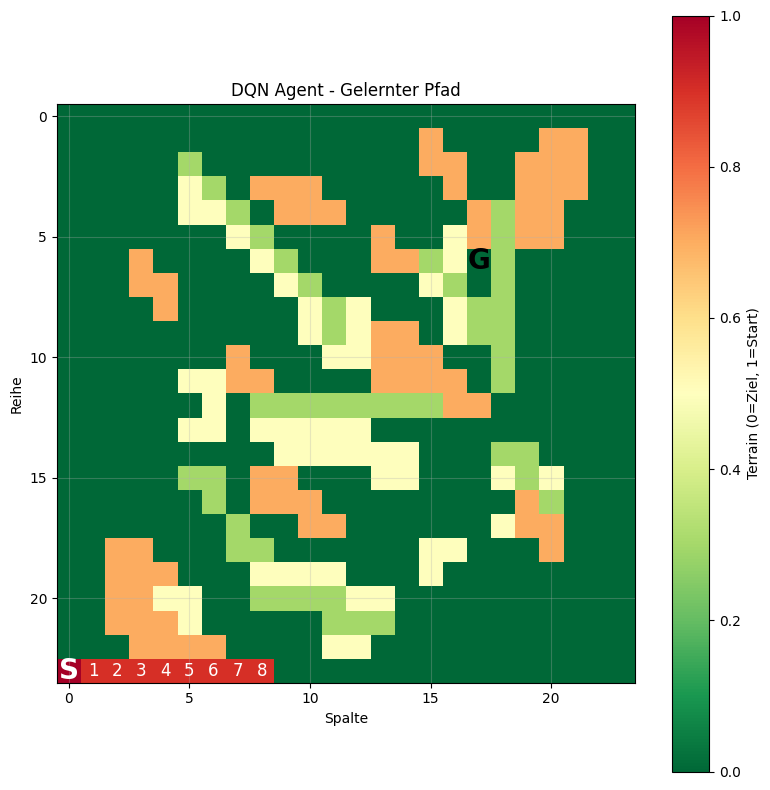

In [30]:
# Visualisierung des Grids mit dem gelernten Pfad
import matplotlib.pyplot as plt

def visualize_path(env, states):
    """Visualisiert das Grid und den Pfad des Agents"""
    grid = np.zeros(env.shape)
    
    # Markiere Hindernisse
    for pos in env.obstacles.get("river", []):
        grid[pos] = 0.3
    for pos in env.obstacles.get("swamp", []):
        grid[pos] = 0.5
    for pos in env.obstacles.get("mountain", []):
        grid[pos] = 0.7
    
    # Markiere Pfad
    for i, state in enumerate(states[:-1]):
        grid[state] = 0.9
    
    # Markiere Start und Ziel
    grid[env.start_position] = 1.0
    grid[env.goal_position] = 0.0
    
    plt.figure(figsize=(8, 8))
    plt.imshow(grid, cmap='RdYlGn_r', interpolation='nearest')
    plt.colorbar(label='Terrain (0=Ziel, 1=Start)')
    
    # Beschriftungen
    for i in range(env.shape[0]):
        for j in range(env.shape[1]):
            if (i, j) == env.start_position:
                plt.text(j, i, 'S', ha='center', va='center', color='white', fontsize=20, weight='bold')
            elif (i, j) == env.goal_position:
                plt.text(j, i, 'G', ha='center', va='center', color='black', fontsize=20, weight='bold')
            elif (i, j) in states:
                step = states.index((i, j))
                plt.text(j, i, str(step), ha='center', va='center', color='white', fontsize=12)
    
    plt.title('DQN Agent - Gelernter Pfad')
    plt.xlabel('Spalte')
    plt.ylabel('Reihe')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

visualize_path(env, states)